In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load

df = pd.read_csv("data/weather.csv", parse_dates = ["time"])
df.head()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,snowfall,weather_code,cloud_cover,pressure_msl,surface_pressure,wind_speed_10m,wind_direction_10m,shortwave_radiation,vapour_pressure_deficit,soil_temperature_0_to_7cm
0,2000-01-01 00:00:00,-4.5,75,-8.3,0.2,0.0,0.14,71,96,1004.9,880.6,1.8,323,0.0,0.11,-2.1
1,2000-01-01 01:00:00,-4.5,76,-8.1,0.1,0.0,0.07,71,94,1004.8,880.6,3.3,319,0.0,0.11,-2.1
2,2000-01-01 02:00:00,-4.6,77,-8.0,0.0,0.0,0.07,71,98,1004.4,880.2,4.3,318,0.0,0.10,-2.1
3,2000-01-01 03:00:00,-4.7,76,-8.3,0.0,0.0,0.07,71,93,1004.0,879.8,4.1,315,0.0,0.11,-2.2
4,2000-01-01 04:00:00,-6.9,75,-10.6,0.0,0.0,0.07,71,97,1004.7,879.4,3.8,311,0.0,0.09,-3.6


In [3]:
# Inspect

# Structure
print(df["time"].min(), "to", df["time"].max(), "\n")
print("Shape:", df.shape, "\n")
print("Dtypes:")
print(df.dtypes, "\n")

# Missingness
print("Nulls:", df.isna().any().any(), "\n")

# Duplicates
print("Missing Rows:", df.duplicated().any(), "\n")
print("Missing Times:", df["time"].duplicated().any(), "\n")

# Sanity
print("Non-Monotonic Times:", not df["time"].is_monotonic_increasing, "\n")
print("Unexpected Time Gaps:", df["time"].diff().dropna().ne(pd.Timedelta(1, "hour")).any())

2000-01-01 00:00:00 to 2026-08-31 23:00:00 

Shape: (233760, 16) 

Dtypes:
time                         datetime64[us]
temperature_2m                      float64
relative_humidity_2m                  int64
dew_point_2m                        float64
precipitation                       float64
rain                                float64
snowfall                            float64
weather_code                          int64
cloud_cover                           int64
pressure_msl                        float64
surface_pressure                    float64
wind_speed_10m                      float64
wind_direction_10m                    int64
shortwave_radiation                 float64
vapour_pressure_deficit             float64
soil_temperature_0_to_7cm           float64
dtype: object 

Nulls: False 

Missing Rows: False 

Missing Times: False 

Non-Monotonic Times: False 

Unexpected Time Gaps: False


In [4]:
# Clean
# No clean required after inspection.

## Notes:

1. Rounding: Weather dataset is tracked hourly, whereas day and night could happen in between.
2. Daytime vs Overnight Definitions
3. Sunrise and Sunset Data

## Rounding: 

Before testing, I lean towards the idea that we should round down for the start of daytime and round up at the end of daytime. The centring point of day is the sun, therefore for the transition period between night and day (sunrise) and later day and night (sunset) we will align towards sun implying day.

After testing, I think it might be better to simply round to the nearest hour.

## Daytime vs Overnight Definitions:

- Daytime: A period of time from the start of Sunrise to the end of Sunset.
- Overnight: A period of time from the end of Sunset to the start of Sunrise.

## Sunrise and Sunset Data

Open-Meteo's ERA5 does not carry sunrise and sunset data. Instead I have collected the following ranges from:
- June: https://www.timeanddate.com/sun/canada/calgary?month=6&year=2026
- July: https://www.timeanddate.com/sun/canada/calgary?month=7&year=2026
- August: https://www.timeanddate.com/sun/canada/calgary?month=8&year=2026

Rounded to the nearest whole hour:
- June 1 - July 7: 5:00am - 10:00pm
- July 8 - July 26: 6:00am - 10:00pm
- July 27 - August 19: 6:00am - 9:00pm
- August 20 - August 27: 7:00am - 9:00pm
- August 27 - August 31: 7:00am - 8:00pm

In [5]:
# Transform

df = df.loc[df["time"].dt.year.eq(2025) & df["time"].dt.month.between(6, 8), ["time", "temperature_2m"]]
df["month"] = df["time"].dt.month_name()

daytime_df = df.loc[df["month"].eq("June") & df["time"].dt.hour.between(5, 22) | 
                    df["month"].eq("July") & df["time"].dt.day.between(1, 7) & df["time"].dt.hour.between(5, 22) | 
                    df["month"].eq("July") & df["time"].dt.day.between(8, 26) & df["time"].dt.hour.between(6, 22) |
                    df["month"].eq("July") & df["time"].dt.day.between(27, 31) & df["time"].dt.hour.between(6, 21) |
                    df["month"].eq("August") & df["time"].dt.day.between(1, 19) & df["time"].dt.hour.between(6, 21) |
                    df["month"].eq("August") & df["time"].dt.day.between(20, 27) & df["time"].dt.hour.between(7, 21) |
                    df["month"].eq("August") & df["time"].dt.day.between(27, 31) & df["time"].dt.hour.between(7, 20)]

daytime_output = daytime_df.groupby(["month"], as_index = False, sort = False).agg(daytime_mean_temp = ("temperature_2m", "mean"))

overnight_df = df.loc[df["month"].eq("June") & df["time"].dt.hour.le(5) | 
                      df["month"].eq("June") & df["time"].dt.hour.ge(22) | 
                      df["month"].eq("July") & df["time"].dt.day.between(1, 7) & df["time"].dt.hour.le(5) |
                      df["month"].eq("July") & df["time"].dt.day.between(1, 7) & df["time"].dt.hour.ge(22) | 
                      df["month"].eq("July") & df["time"].dt.day.between(8, 26) & df["time"].dt.hour.le(6) |
                      df["month"].eq("July") & df["time"].dt.day.between(8, 26) & df["time"].dt.hour.ge(22) |
                      df["month"].eq("July") & df["time"].dt.day.between(27, 31) & df["time"].dt.hour.le(6) |
                      df["month"].eq("July") & df["time"].dt.day.between(27, 31) & df["time"].dt.hour.ge(21) |
                      df["month"].eq("August") & df["time"].dt.day.between(1, 19) & df["time"].dt.hour.le(6) |
                      df["month"].eq("August") & df["time"].dt.day.between(1, 19) & df["time"].dt.hour.ge(21) |
                      df["month"].eq("August") & df["time"].dt.day.between(20, 27) & df["time"].dt.hour.le(7) |
                      df["month"].eq("August") & df["time"].dt.day.between(20, 27) & df["time"].dt.hour.ge(21) |
                      df["month"].eq("August") & df["time"].dt.day.between(27, 31) & df["time"].dt.hour.le(7) |
                      df["month"].eq("August") & df["time"].dt.day.between(27, 31) & df["time"].dt.hour.ge(20)]

overnight_output = overnight_df.groupby(["month"], as_index = False, sort = False).agg(overnight_mean_temp = ("temperature_2m", "mean"))

output_df = daytime_output.merge(overnight_output)
output_df

,month,daytime_mean_temp,overnight_mean_temp
0,June,16.615556,11.239583
1,July,17.324008,12.984838
2,August,19.421042,13.328440


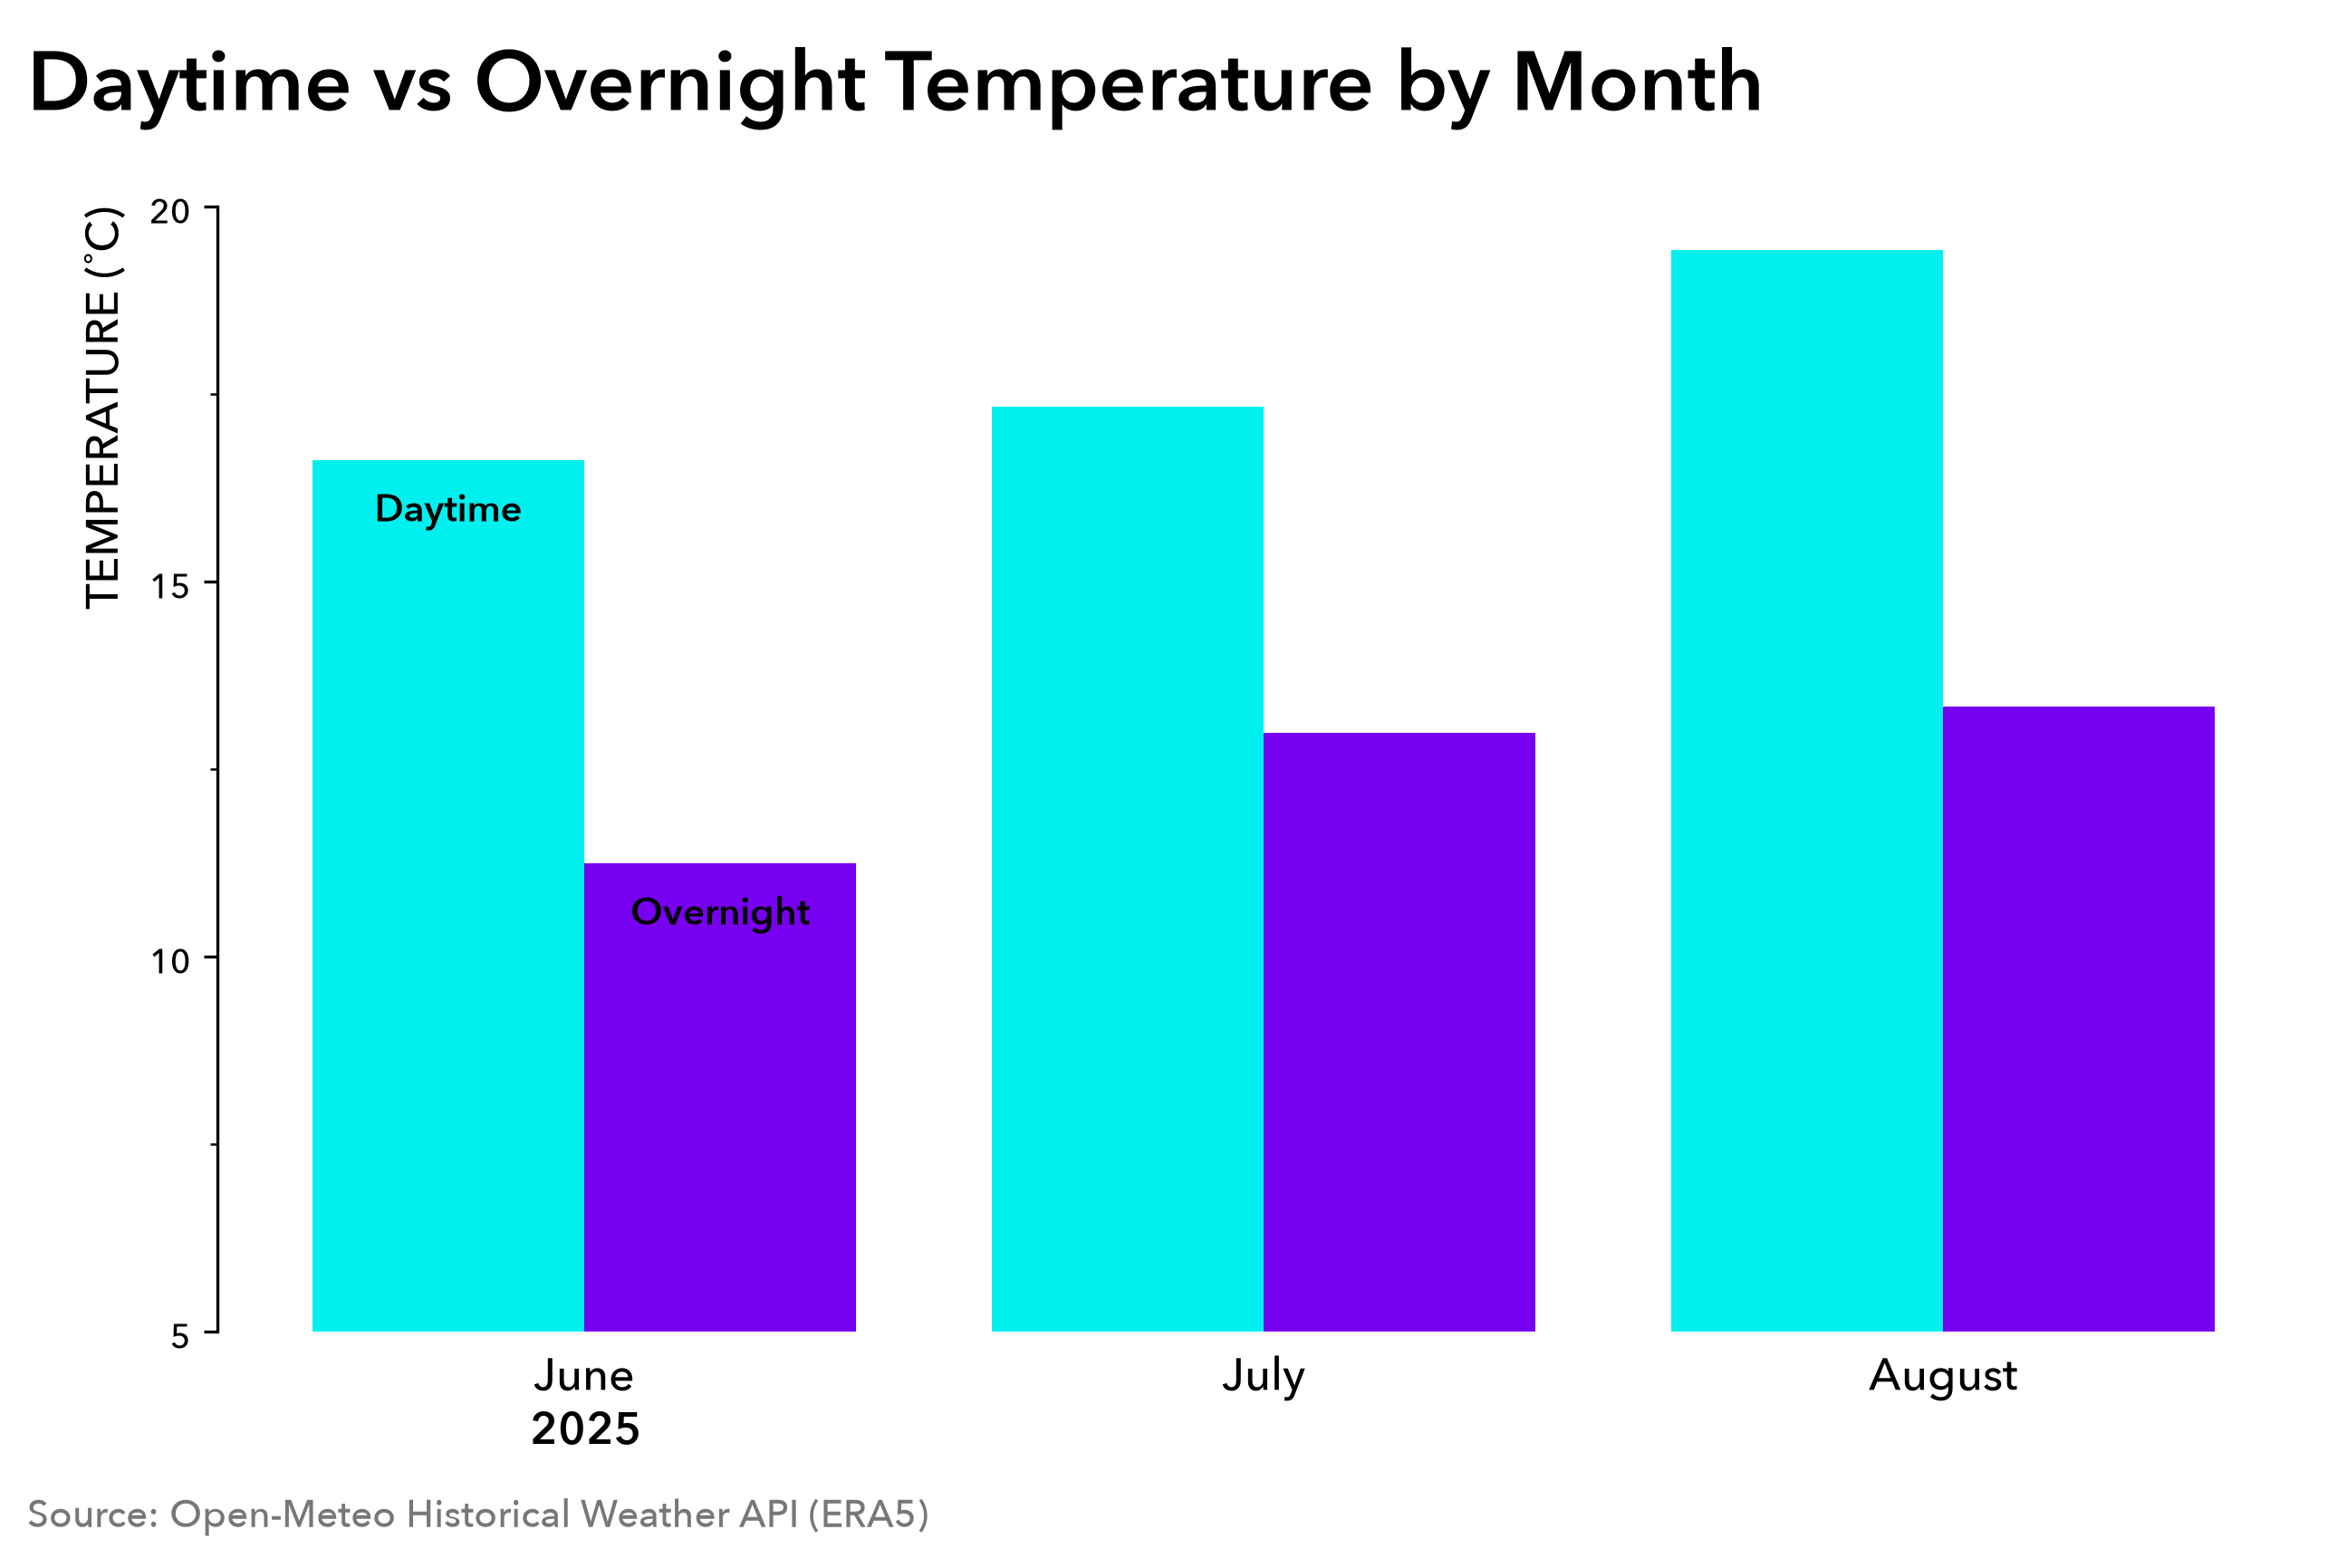

In [6]:
# Visualize

# Figure

plt.rcParams["font.family"] = "Avenir Next"
plt.rcParams["font.weight"] = 500

fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)

plt.subplots_adjust(
    left = 0.13,
    right = 0.9,
    top = 0.83,
    bottom = 0.14
)

# Plot

daytime_bars = plt.bar(output_df["month"], output_df["daytime_mean_temp"], width = -0.4, align = "edge", color = "#00F0F0", label = "Daytime")
overnight_bars = plt.bar(output_df["month"], output_df["overnight_mean_temp"], width = 0.4, align = "edge", color = "#7800F0", label = "Overnight")

# Scale & Axes

ax.set_ylim(5, 20)

ax.set_ylabel("TEMPERATURE (˚C)", loc = "top", fontsize = 12, fontweight = 500)

fig.text(-0.08, -0.1, "2025", transform=ax.get_xaxis_transform(), fontsize = 12, fontweight = 600)

# Ticks

ax.set_yticks([5, 10, 15, 20])
ax.set_yticks([7.5, 12.5, 17.5], minor = True)

ax.tick_params(
    axis = "x",
    labelsize = 12,
    length = 0)

ax.tick_params(
    axis = "y",
    labelsize = 9)

# Styling
ax.spines[["top", "right", "bottom"]].set_visible(False)

#ax.legend(loc = "upper right")

ax.text(daytime_bars[0].get_x() - 0.2, daytime_bars[0].get_height() - 1, "Daytime", ha = "center", va = "bottom", fontweight = 600, fontsize = 10)
ax.text(overnight_bars[0].get_x() + 0.2, overnight_bars[0].get_height() - 1, "Overnight", ha = "center", va = "bottom", fontweight = 600, fontsize = 10)

# Composition

fig.suptitle("Daytime vs Overnight Temperature by Month", x = 0.06, y = 0.94, ha = "left", va = "top", fontweight = 600, fontsize = 22)

fig.text(0.06, 0.02, "Source: Open-Meteo Historical Weather API (ERA5)", fontsize = 10, color = "#777777")

# Output
fig.savefig("outputs/blind-daytime-vs-overnight-temperature-summer-2025.svg", bbox_inches = "tight", pad_inches = 0.1)
plt.show()